In [1]:
from pathlib import Path

import pandas as pd
from matplotlib import pyplot as plt
from rtnls_fundusprep import FundusPreprocessor
from rtnls_models import preprocess_for_inference
from vascx.utils.data_loading import load_image

## Preprocessing

This code will preprocess the images and write .npy files with the square fundus image and the contrast enhanced version

This step is not strictly necessary, but it is useful if you want to run the preprocessing step separately before model inference

In [2]:
ds_path = Path("../../samples/fundus")
rgb_path = ds_path / "rgb"

In [3]:
files = list(rgb_path.glob("*.png"))

In [4]:
bounds = preprocess_for_inference(
    files,
    rgb_path=ds_path / "preprocessed_rgb",
    npy_path=ds_path / "preprocessed_npy",
    n_jobs=4,
)
df_bounds = pd.DataFrame(bounds).set_index("id")
df_bounds.index = df_bounds.index.map(int)

0it [00:00, ?it/s][Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
10it [00:05,  1.95it/s]
[Parallel(n_jobs=4)]: Done   5 out of  10 | elapsed:    7.1s remaining:    7.1s
[Parallel(n_jobs=4)]: Done   7 out of  10 | elapsed:    9.9s remaining:    4.2s
[Parallel(n_jobs=4)]: Done  10 out of  10 | elapsed:   11.8s finished


In [5]:
# df_bounds contains the bounds of each image (circle and rectangle)
# this information can be used to "reconstruct" the original fundus
# or to transform model output to make it match the original image
df_bounds.to_csv(ds_path / "meta.csv")

## FundusPreprocessor

Here we use the fundus preprocessor directly to preprocess and plot a single image

In [6]:
im_path = ds_path / "rgb/360268.png"

In [7]:
prep_function = FundusPreprocessor(
    square_size=1024,
    contrast_enhance=True,
)

In [8]:
im_orig = load_image(im_path)

In [9]:
(im, ce), tg, bounds = prep_function(im_orig)

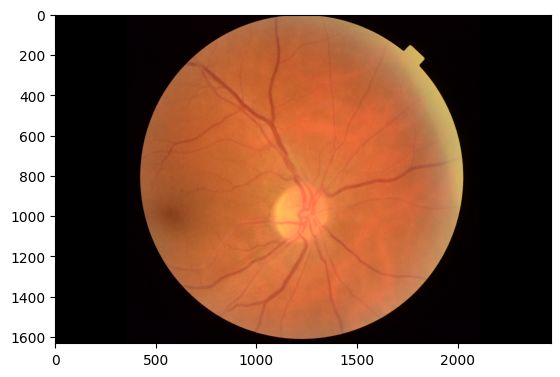

In [10]:
plt.imshow(im_orig)

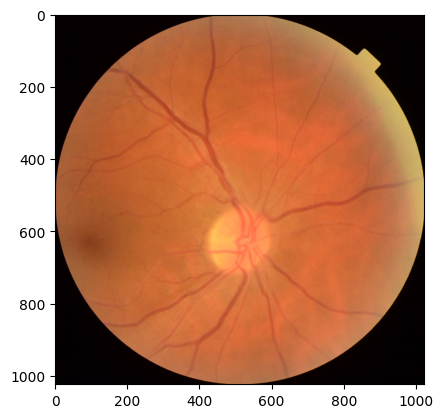

In [11]:
plt.imshow(im)

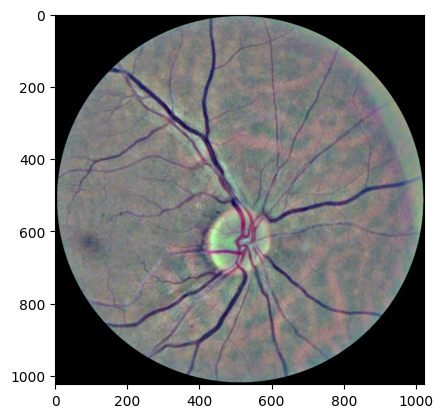

In [12]:
plt.imshow(ce)